# **Deep Learning for Natural Language Processing - AIL7390**
## **Assignment - 2**

**Name:** Irwindeep Singh\
**Roll No.:** B22AI022

## **Dataset Upload**

In [ ]:
from google.colab.files import upload_file
upload_file("dataset.zip")

!unzip -q dataset.zip

Saved dataset.zip to /content/dataset.zip


## **Necessary Imports**

In [ ]:
!pip install -q nltk bert-score torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 9.6 kB/s eta 0:00:00


In [ ]:
import os
import time
from typing import List, Literal, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from bert_score import score as bertscore
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    MT5ForConditionalGeneration,
    logging,
)

logging.set_verbosity_error()
logging.disable_progress_bar()

plt.rcParams["font.family"] = "STIXGeneral"

RANDOM_SEED = 0xDEADBEEF
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PRETRAINED_MODEL = "google/mt5-small"
DATA_ROOT = "dataset"

BATCH_SIZE = 8
MAX_SOURCE_LEN = 128
MAX_TARGET_LEN = 128
EPOCHS = 5
LR = 2e-5
GRAD_CLIP = 0.5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

## **Dataset and DataLoader**

In [ ]:
def _first_existing_path(*paths: str) -> str:
    for path in paths:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"None of these files exist: {paths}")


class SanskritEnglishDataset(Dataset):
    def __init__(
        self,
        root: str,
        split: Literal["train", "dev", "test"],
        sanskrit_label: str = "sa",
        english_label: str = "en",
    ) -> None:
        super().__init__()

        sanskrit_csv = _first_existing_path(
            os.path.join(root, f"{split}_{sanskrit_label}.csv"),
            os.path.join(root, f"{split} {sanskrit_label}.csv"),
        )
        english_csv = _first_existing_path(
            os.path.join(root, f"{split}_{english_label}.csv"),
            os.path.join(root, f"{split} {english_label}.csv"),
        )

        sanskrit_df = pd.read_csv(sanskrit_csv)
        english_df = pd.read_csv(english_csv)

        if len(sanskrit_df) != len(english_df):
            raise RuntimeError(
                f"{sanskrit_csv} and {english_csv} have different lengths "
                "and cannot be aligned one-to-one."
            )

        self.df = (
            sanskrit_df[["Source_id", "Sentence_sa"]]
            .merge(
                english_df[["Source_id", "Sentence_en"]],
                on="Source_id",
                how="inner",
                validate="one_to_one",
            )
            .sort_values("Source_id")
            .reset_index(drop=True)
        )

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int) -> Tuple[int, str, str]:
        row = self.df.iloc[index]
        source_id = int(row["Source_id"])
        sanskrit = str(row["Sentence_sa"])
        english = str(row["Sentence_en"])
        return source_id, sanskrit, english


class Seq2SeqCollator:
    def __init__(self, tokenizer, max_source_len: int, max_target_len: int) -> None:
        self.tokenizer = tokenizer
        self.max_source_len = max_source_len
        self.max_target_len = max_target_len

    def __call__(self, batch):
        source_ids, sources, targets = zip(*batch)

        sources = [f"translate Sanskrit to English: {s}" for s in sources]

        model_inputs = self.tokenizer(
            list(sources),
            max_length=self.max_source_len,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )

        labels = self.tokenizer(
            text_target=list(targets),
            max_length=self.max_target_len,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )

        labels_ids = labels["input_ids"]
        labels_ids[labels_ids == self.tokenizer.pad_token_id] = -100

        model_inputs["labels"] = labels_ids
        model_inputs["source_ids"] = list(source_ids)
        model_inputs["targets"] = list(targets)

        return model_inputs

In [ ]:
train_dataset = SanskritEnglishDataset(root=DATA_ROOT, split="train")
val_dataset = SanskritEnglishDataset(root=DATA_ROOT, split="dev")
test_dataset = SanskritEnglishDataset(root=DATA_ROOT, split="test")

print(" Dataset Config ".center(60, "-"))
print(f"{'Train Samples':>30}: {len(train_dataset):,}")
print(f"{'Validation Samples':>30}: {len(val_dataset):,}")
print(f"{'Test Samples':>30}: {len(test_dataset):,}")
print("".center(60, "-"))

collate_fn = Seq2SeqCollator(tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

print(" DataLoader Config ".center(60, "-"))
print(f"{'Train Batches':>30}: {len(train_loader):,}")
print(f"{'Validation Batches':>30}: {len(val_loader):,}")
print(f"{'Test Batches':>30}: {len(test_loader):,}")
print("".center(60, "-"))

indices = torch.randint(low=0, high=len(train_dataset) - 1, size=(5,))
print("\nExample Pairs:\n")
for i, idx in enumerate(indices, start=1):
    sid, sa, en = train_dataset[int(idx)]
    print(f"{i}. Source id: {sid}")
    print(f"   SA: {sa}")
    print(f"   EN: {en}\n")

---------------------- Dataset Config ----------------------
                 Train Samples: 10,000
            Validation Samples: 1,000
                  Test Samples: 1,000
------------------------------------------------------------
-------------------- DataLoader Config ---------------------
                 Train Batches: 1,250
            Validation Batches: 125
                  Test Batches: 125
------------------------------------------------------------

Example Pairs:

1. Source id: 4940
   SA: "अस्य उदाहरणानि- उष्णवायु:, मृत्तिका, अग्नि:"
   EN: "for eg.-hot air, sand, fire."

2. Source id: 6407
   SA: किन्तु ते मम नामकारणाद् युष्मान् प्रति तादृशं व्यवहरिष्यन्ति यतो यो मां प्रेरितवान् तं ते न जानन्ति।
   EN: "But all these things will they do unto you for my name's sake, because they know not him that sent me."

3. Source id: 5123
   SA: अन्यथा, कृपया  अस्मिन् जालपुटे Koha spoken tutorial  सरणिं पश्यन्तु ।
   EN: If not, please refer to the Koha Spoken Tutorial series on t

## **Model**

In [ ]:
class MT5Translator(nn.Module):
    def __init__(self, pretrained_model: str = PRETRAINED_MODEL) -> None:
        super().__init__()
        self.model = MT5ForConditionalGeneration.from_pretrained(pretrained_model)

    def forward(self, **batch):
        return self.model(**batch)

    @torch.no_grad()
    def generate_text(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        max_new_tokens: int = MAX_TARGET_LEN,
        num_beams: int = 4,
    ) -> torch.Tensor:
        return self.model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
        )

In [ ]:
model = MT5Translator().to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(" Model Config ".center(60, "-"))
print(f"{'Total Parameters':>30}: {num_params:,}")
print(f"{'Trainable Parameters':>30}: {trainable_params:,}")
print("".center(60, "-"))

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

steps_per_epoch = len(train_loader)
num_training_steps = EPOCHS * steps_per_epoch

----------------------- Model Config -----------------------
              Total Parameters: 556,291,456
          Trainable Parameters: 556,291,456
------------------------------------------------------------


## **Model Training**

In [ ]:
def decode_predictions(token_ids: torch.Tensor) -> List[str]:
    token_ids = token_ids.detach().cpu()
    token_ids[token_ids == -100] = tokenizer.pad_token_id
    return tokenizer.batch_decode(token_ids, skip_special_tokens=True)

@torch.no_grad()
def evaluate_loader(loader: DataLoader) -> Tuple[float, float, float]:
    model.eval()

    losses: List[float] = []
    references: List[List[List[str]]] = []
    hypotheses: List[List[str]] = []
    pred_texts: List[str] = []
    ref_texts: List[str] = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        source_ids = batch.pop("source_ids")
        targets = batch.pop("targets")

        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16):
            outputs = model(**batch)
            loss = outputs.loss

        losses.append(loss.item())

        generated = model.generate_text(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            max_new_tokens=MAX_TARGET_LEN,
            num_beams=4,
        )

        preds = tokenizer.batch_decode(generated, skip_special_tokens=True)
        pred_texts.extend([p.strip() for p in preds])
        ref_texts.extend([t.strip() for t in targets])

        for ref in targets:
            references.append([ref.strip().split()])
        for pred in preds:
            hypotheses.append(pred.strip().split())

    bleu = corpus_bleu(
        references,
        hypotheses,
        smoothing_function=SmoothingFunction().method1,
    )

    if len(ref_texts) > 0:
        p, r, f1 = bertscore(
            pred_texts,
            ref_texts,
            lang="en",
            rescale_with_baseline=True,
            verbose=False,
        )
        bert_f1 = float(f1.mean().item())
    else:
        bert_f1 = 0.0

    return float(np.mean(losses)), float(bleu), bert_f1

In [ ]:
def train_epoch(epoch: int) -> float:
    model.train()
    total_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch[{epoch}/{EPOCHS}]")
    for batch in pbar:
        batch.pop("source_ids")
        batch.pop("targets")
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16):
            outputs = model(**batch)
            loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({"Train Loss": f"{total_loss / max(1, pbar.n + 1):.4f}"})

    return total_loss / len(train_loader)

In [ ]:
best_val_loss = float("inf")
history = {
    "train_loss": [],
    "val_loss": [],
    "val_bleu": [],
    "val_bertscore": [],
}

os.makedirs("checkpoints", exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(epoch)
    val_loss, val_bleu, val_bertscore = evaluate_loader(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_bleu"].append(val_bleu)
    history["val_bertscore"].append(val_bertscore)

    print(
        f"[Epoch {epoch:02d}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"BLEU: {val_bleu:.4f} | "
        f"BERTScore(F1): {val_bertscore:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "tokenizer_name": PRETRAINED_MODEL,
                "epoch": epoch,
                "val_loss": val_loss,
            },
            "checkpoints/mt5_best.pt",
        )

Epoch[1/5]:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/125 [00:00<?, ?it/s]

[Epoch 01] Train Loss: 9.4033 | Val Loss: 3.8887 | BLEU: 0.0096 | BERTScore(F1): 0.1184


Epoch[2/5]:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/125 [00:00<?, ?it/s]

[Epoch 02] Train Loss: 4.6914 | Val Loss: 3.5523 | BLEU: 0.0162 | BERTScore(F1): 0.1821


KeyboardInterrupt: 

## **Visualizations**

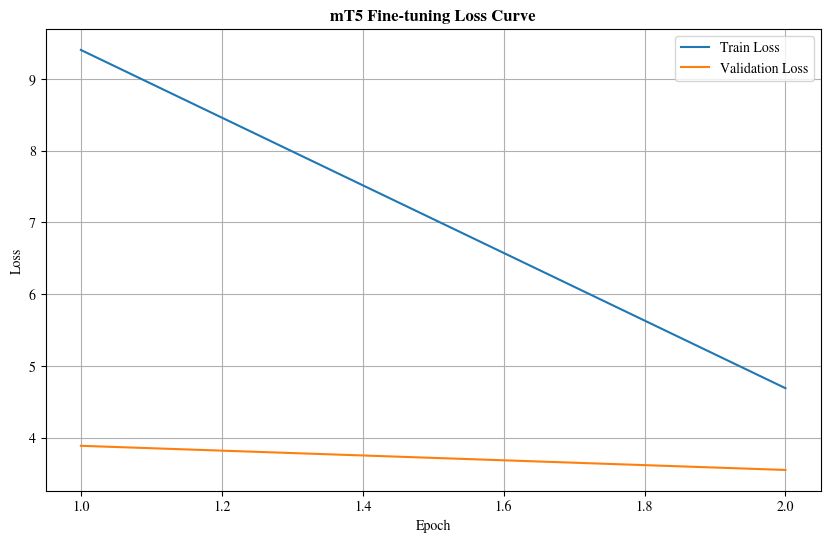

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 2 + 1), history["train_loss"], label="Train Loss")
plt.plot(range(1, 2 + 1), history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("mT5 Fine-tuning Loss Curve", fontweight="bold")
plt.grid()
plt.legend()
plt.savefig("mt5_loss_curve.pdf", bbox_inches="tight")

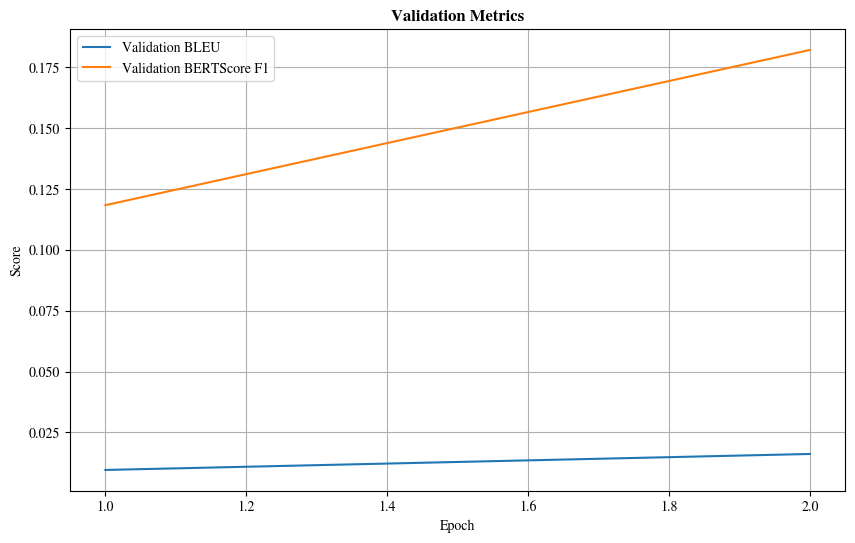

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 2 + 1), history["val_bleu"], label="Validation BLEU")
plt.plot(
    range(1, 2 + 1), history["val_bertscore"], label="Validation BERTScore F1"
)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics", fontweight="bold")
plt.grid()
plt.legend()
plt.savefig("mt5_metrics_curve.pdf", bbox_inches="tight")

In [ ]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

## **Inference and Evaluation**

In [2]:
from google.colab import files

files.upload_file("test_sa.csv")
files.upload_file("test_en.csv")

Saved test_demo_sa - Sheet1.csv to /content/test_sa.csv


Saved test_demo_en - Sheet1.csv to /content/test_en.csv


In [5]:
%pip install -q bert_score nltk torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.4 MB/s eta 0:00:00


In [14]:
import os
import time
from typing import List, Literal, Tuple

import numpy as np
import pandas as pd
import torch
import gdown
import pickle
import torch.nn as nn
from bert_score import score as bertscore
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    MT5ForConditionalGeneration,
    logging,
)

logging.set_verbosity_error()
logging.disable_progress_bar()

RANDOM_SEED = 0xDEADBEEF
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PRETRAINED_MODEL = "google/mt5-small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_TARGET_LEN = 128
MAX_SOURCE_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [10]:
class MT5Translator(nn.Module):
    def __init__(self, pretrained_model: str = PRETRAINED_MODEL) -> None:
        super().__init__()
        self.model = MT5ForConditionalGeneration.from_pretrained(pretrained_model)

    def forward(self, **batch):
        return self.model(**batch)

    @torch.no_grad()
    def generate_text(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        max_new_tokens: int = MAX_TARGET_LEN,
        num_beams: int = 4,
    ) -> torch.Tensor:
        return self.model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
        )

In [11]:
MODEL_ID = "1uDWDLqL-Dj7hvnf73DY6xIaoFXBumKDd"
MODEL_FILE = "model.pkl"

gdown.download(id=MODEL_ID, output=MODEL_FILE)

with open(MODEL_FILE, "rb") as file:
    model = pickle.load(file)
    model.to(DEVICE)
    model.eval()

sa_texts = pd.read_csv("test_sa.csv")
en_texts = pd.read_csv("test_en.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1uDWDLqL-Dj7hvnf73DY6xIaoFXBumKDd
From (redirected): https://drive.google.com/uc?id=1uDWDLqL-Dj7hvnf73DY6xIaoFXBumKDd&confirm=t&uuid=045a055e-2f83-48c4-bb78-b229a1f00444
To: /content/model.pkl
100%|██████████| 2.23G/2.23G [00:48<00:00, 45.5MB/s]


In [15]:
@torch.no_grad()
def translate_batch(
    sources: List[str],
    max_source_len: int = MAX_SOURCE_LEN,
    max_new_tokens: int = MAX_TARGET_LEN,
    num_beams: int = 4,
) -> List[str]:
    model.eval()

    inputs = tokenizer(
        [f"translate Sanskrit to English: {s}" for s in sources],
        max_length=max_source_len,
        padding=True,
        truncation=True,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16):
        outputs = model.generate_text(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
        )

    texts = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return [t.strip() for t in texts]

In [16]:
@torch.no_grad()
def evaluate_dataframe(
    df: pd.DataFrame,
    batch_size: int = 16,
) -> Tuple[List[int], List[str], float]:
    model.eval()
    start_time = time.time()

    source_ids = df["Source_id"].tolist()
    sources = df["Sentence_sa"].astype(str).tolist()

    all_predictions: List[str] = []
    for i in tqdm(range(0, len(sources), batch_size), desc="Translating"):
        batch_sources = sources[i : i + batch_size]

        preds = translate_batch(batch_sources)
        all_predictions.extend(preds)

    elapsed = time.time() - start_time

    return source_ids, all_predictions, elapsed

def save_submission_csv_from_df(
    df: pd.DataFrame,
    filepath: str = "submission.csv",
) -> pd.DataFrame:

    source_ids, predictions, elapsed = evaluate_dataframe(df)

    submission_df = pd.DataFrame(
        {
            "Source_id": source_ids,
            "Sentence_en": predictions,
        }
    ).sort_values("Source_id")

    submission_df.to_csv(filepath, index=False, encoding="utf-8")

    print(f"Saved: {filepath}")
    print(f"Total inference time: {elapsed:.2f} seconds")
    print(f"Rows written: {len(submission_df):,}")

    return submission_df

In [17]:
num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(" Model Config ".center(60, "-"))
print(f"{'Total Parameters':>30}: {num_params:,}")
print(f"{'Trainable Parameters':>30}: {trainable_params:,}")
print("".center(60, "-"))

----------------------- Model Config -----------------------
              Total Parameters: 556,291,456
          Trainable Parameters: 556,291,456
------------------------------------------------------------


In [25]:
submission_df = save_submission_csv_from_df(sa_texts, "submission.csv")
submission_df.head()

Translating:   0%|          | 0/7 [00:00<?, ?it/s]

Saved: submission.csv
Total inference time: 29.18 seconds
Rows written: 100


,Source_id,Sentence_en
0,1001,"""And when they shall be aware of the truth of ..."
1,1002,"""Then, we have a display of the display of the..."
2,1003,"""The admin role is a student."
3,1004,The course is a course.
4,1005,"Now, we will learn about the lessons of the st..."


In [26]:
bleu = corpus_bleu(
    submission_df["Sentence_en"],
    en_texts["Sentence_en"],
    smoothing_function=SmoothingFunction().method1,
)

p, r, f1 = bertscore(
    submission_df["Sentence_en"].tolist(),
    en_texts["Sentence_en"].tolist(),
    lang="en",
    rescale_with_baseline=True,
    verbose=False,
)
bert_f1 = float(f1.mean().item())

print(f"BLEU Score: {bleu:.4f}")
print(f"BERTScore: {bert_f1:.4f}")

BLEU Score: 0.0002
BERTScore: 0.1567
